# 📊 Semana 1: Carga de Datos y Visualización Básica

## Objetivos
- Aprender a cargar DataFrames desde diferentes fuentes: CSV, Excel, GitHub y Google Sheets
- Realizar exploración inicial de los datos
- Crear visualizaciones básicas con **Matplotlib**, **Seaborn** y **Plotly Express**

## Dataset: Water Quality (Calidad del Agua)
Utilizaremos un dataset de calidad del agua que contiene mediciones fisicoquímicas:
- `ph`: Nivel de pH del agua
- `Hardness`: Dureza del agua (mg/L)
- `Solids`: Sólidos disueltos totales (ppm)
- `Chloramines`: Cantidad de cloraminas (ppm)
- `Sulfate`: Cantidad de sulfatos (mg/L)
- `Conductivity`: Conductividad eléctrica (μS/cm)
- `Organic_carbon`: Carbono orgánico (ppm)
- `Trihalomethanes`: Trihalometanos (μg/L)
- `Turbidity`: Turbidez (NTU)
- `Potability`: Potabilidad (1 = potable, 0 = no potable)

---
## 1. Instalación e Importación de Librerías

In [ ]:

# =============================================================================
# CONCEPTO: Importación de librerías
# -----------------------------------------------------------------------------
# Antes de trabajar con datos, se deben importar las librerías necesarias.
# Cada librería tiene un propósito específico:
#   - pandas (pd):      Manipulación y análisis de datos tabulares (DataFrames).
#   - numpy (np):       Operaciones numéricas y matriciales de alto rendimiento.
#   - matplotlib.pyplot (plt): Librería base de visualización estática en Python.
#   - seaborn (sns):    Visualización estadística de alto nivel sobre Matplotlib.
#   - plotly.express (px): Gráficos interactivos con una API sencilla.
#
# CRITERIO DE USO: Importar siempre al inicio del notebook para que estén
# disponibles en todas las celdas siguientes.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuración de visualización
# plt.style.use(): Aplica un tema visual global a todos los gráficos de Matplotlib.
# 'seaborn-v0_8-whitegrid' genera un fondo blanco con rejilla, limpio y legible.
plt.style.use('seaborn-v0_8-whitegrid')

# sns.set_palette(): Define la paleta de colores por defecto en Seaborn.
# 'husl' es una paleta perceptualmente uniforme, ideal para variables categóricas.
sns.set_palette('husl')

# pd.set_option(): Ajusta el comportamiento de visualización de pandas.
# 'display.max_columns', None → muestra todas las columnas sin truncar.
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


---
## 2. Carga de Datos desde CSV

La función `pd.read_csv()` es la forma más común de cargar datos en pandas. Acepta parámetros como:
- `sep`: separador de columnas (por defecto `,`)
- `encoding`: codificación del archivo (`utf-8`, `latin-1`, etc.)
- `header`: fila que contiene los nombres de columnas
- `na_values`: valores adicionales que se interpretan como nulos
- `usecols`: seleccionar columnas específicas

In [ ]:

# =============================================================================
# CONCEPTO: Carga de datos con pd.read_csv()
# -----------------------------------------------------------------------------
# pd.read_csv() lee un archivo CSV y lo convierte en un DataFrame de pandas.
# Es la función de carga más utilizada porque el formato CSV es ampliamente
# compatible con Excel, bases de datos y herramientas de ciencia de datos.
#
# CRITERIO DE USO:
#   - Usar ruta local cuando el archivo está disponible en el equipo.
#   - Usar URL raw cuando el archivo está alojado en un repositorio público,
#     lo que garantiza reproducibilidad sin depender de archivos locales.
#
# La URL "raw" de GitHub apunta directamente al contenido del archivo,
# sin el envoltorio HTML de la interfaz web de GitHub.
# =============================================================================

# df = pd.read_csv('water_potability.csv')  # Descomentar si tienes el archivo local

# Cargaremos desde GitHub para que funcione sin archivo local
url_csv = "https://raw.githubusercontent.com/jaquimbayoc7/material-fundamentos_datos/refs/heads/main/data/water_potability.csv"
df = pd.read_csv(url_csv)

# df.shape devuelve una tupla (n_filas, n_columnas): permite verificar
# rápidamente que el archivo se cargó completo y con la estructura esperada.
print(f"✅ Dataset cargado exitosamente")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")


✅ Dataset cargado exitosamente
Filas: 3276, Columnas: 10


In [ ]:

# =============================================================================
# CONCEPTO: Parámetros avanzados de pd.read_csv()
# -----------------------------------------------------------------------------
# pd.read_csv() acepta múltiples parámetros para adaptarse a distintos formatos
# de archivos CSV. Conocerlos evita errores de lectura y pérdida de datos.
#
# Parámetros clave:
#   sep=';'              → archivos donde las columnas se separan con punto y coma
#                          (formato europeo o exportaciones de Excel en español).
#   encoding='latin-1'  → necesario cuando el archivo contiene tildes, ñ u otros
#                          caracteres especiales que no son UTF-8.
#   na_values=[...]      → lista de cadenas adicionales que pandas interpretará
#                          como NaN (valor nulo), útil cuando los datos usan
#                          etiquetas propias para valores faltantes.
#   usecols=[...]        → carga solo las columnas especificadas, reduciendo el
#                          uso de memoria en datasets grandes.
#
# CRITERIO DE USO: Aplicar usecols cuando solo se necesita un subconjunto de
# columnas para análisis; mejora el rendimiento en archivos con muchas columnas.
# =============================================================================

# 1. Especificar separador (ej. archivos separados por punto y coma)
# df_semicolon = pd.read_csv('archivo.csv', sep=';')

# 2. Especificar encoding (común en archivos con acentos/ñ)
# df_latin = pd.read_csv('archivo.csv', encoding='latin-1')

# 3. Definir valores nulos personalizados
# df_na = pd.read_csv('archivo.csv', na_values=['N/A', 'Sin dato', '-'])

# 4. Seleccionar solo algunas columnas con usecols
# Se limita la carga a 3 columnas relevantes; el resultado es un DataFrame más
# pequeño y liviano ideal para pruebas rápidas o análisis parciales.
df_parcial = pd.read_csv(url_csv, usecols=['ph', 'Hardness', 'Potability'])
print("Carga parcial (solo 3 columnas):")
df_parcial.head()


Carga parcial (solo 3 columnas):


,ph,Hardness,Potability
0,NaN,204.890455,0
1,3.716080,129.422921,0
2,8.099124,224.236259,0
3,8.316766,214.373394,0
4,9.092223,181.101509,0


In [ ]:

# =============================================================================
# CONCEPTO: Inspección inicial con head() y tail()
# -----------------------------------------------------------------------------
# Después de cargar un DataFrame, es buena práctica visualizar las primeras y
# últimas filas para confirmar que:
#   - Las columnas tienen los nombres correctos.
#   - Los tipos de datos parecen coherentes (ej. números, no texto).
#   - No hay filas de encabezado duplicadas ni filas de resumen al final.
#
#   df.head(n): devuelve las primeras n filas (por defecto 5).
#   df.tail(n): devuelve las últimas n filas (por defecto 5).
#
# CRITERIO DE USO: Siempre inspeccionar inicio y fin del dataset al cargarlo;
# los errores de formato suelen aparecer en los extremos del archivo.
# =============================================================================

print("=" * 60)
print("PRIMERAS 5 FILAS")
print("=" * 60)
display(df.head())   # Muestra estructura general y primeros valores

print("\n" + "=" * 60)
print("ÚLTIMAS 5 FILAS")
print("=" * 60)
display(df.tail())   # Verifica que el archivo no tenga filas de total o notas al pie


PRIMERAS 5 FILAS


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



ÚLTIMAS 5 FILAS


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


---
## 3. Carga de Datos desde Excel

La función `pd.read_excel()` permite leer archivos `.xlsx` y `.xls`. Requiere el motor `openpyxl`.

Parámetros útiles:
- `sheet_name`: nombre o índice de la hoja (por defecto la primera)
- `header`: fila con los nombres de columnas
- `usecols`: rango de columnas (ej. `'A:E'`)
- `engine`: motor de lectura (`openpyxl` para .xlsx)

In [ ]:

# =============================================================================
# CONCEPTO: Escritura y lectura de archivos Excel con pandas
# -----------------------------------------------------------------------------
# pd.read_excel() carga un archivo .xlsx o .xls como DataFrame.
# Requiere la librería openpyxl (para .xlsx) instalada en el entorno.
#
# Flujo demostrado aquí:
#   1. df.to_excel(): exporta el DataFrame a un archivo Excel.
#      - sheet_name: nombre de la hoja de cálculo dentro del archivo.
#      - index=False: evita que pandas escriba el índice numérico como columna extra.
#   2. pd.read_excel(): vuelve a leer el archivo generado para demostrar la lectura.
#      - engine='openpyxl': motor necesario para archivos .xlsx modernos.
#
# CRITERIO DE USO: Usar Excel cuando se comparten datos con usuarios de hojas
# de cálculo o cuando el origen de los datos es un archivo .xlsx empresarial.
# =============================================================================

# Paso 1: Guardar el DataFrame como Excel (genera un archivo local de demostración)
df.to_excel('water_potability_demo.xlsx', sheet_name='Datos', index=False)
print("✅ Archivo Excel creado: water_potability_demo.xlsx")

# Paso 2: Leer el archivo Excel recién creado
# sheet_name='Datos' indica qué hoja cargar (útil cuando el archivo tiene múltiples hojas)
df_excel = pd.read_excel('water_potability_demo.xlsx', sheet_name='Datos', engine='openpyxl')
print(f"\nDatos cargados desde Excel: {df_excel.shape[0]} filas x {df_excel.shape[1]} columnas")
df_excel.head()


✅ Archivo Excel creado: water_potability_demo.xlsx

Datos cargados desde Excel: 3276 filas x 10 columnas


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:

# =============================================================================
# CONCEPTO: Carga parcial de columnas desde Excel con usecols
# -----------------------------------------------------------------------------
# El parámetro usecols en pd.read_excel() acepta:
#   - Una cadena estilo Excel como 'A:D' → selecciona las columnas A hasta D.
#   - Una lista de nombres de columna → selecciona columnas por nombre.
#
# CRITERIO DE USO: Aplicar cuando el archivo Excel tiene muchas columnas
# (ej. decenas o centenas) y solo se necesita un subconjunto para el análisis.
# Reduce el uso de memoria y acelera la carga.
# =============================================================================

# usecols='A:D' carga solo las primeras 4 columnas del archivo
# (equivalente a las columnas ph, Hardness, Solids, Chloramines en este dataset)
df_excel_parcial = pd.read_excel(
    'water_potability_demo.xlsx',
    sheet_name='Datos',
    usecols='A:D',    # Selección por rango de letra de columna (notación Excel)
    engine='openpyxl'
)
print("Lectura parcial (columnas A:D):")
df_excel_parcial.head()


Lectura parcial (columnas A:D):


,ph,Hardness,Solids,Chloramines
0,NaN,204.890455,20791.318981,7.300212
1,3.716080,129.422921,18630.057858,6.635246
2,8.099124,224.236259,19909.541732,9.275884
3,8.316766,214.373394,22018.417441,8.059332
4,9.092223,181.101509,17978.986339,6.546600


---
## 4. Carga de Datos desde la Nube — GitHub

Podemos cargar datos directamente desde un repositorio de GitHub usando la URL **raw** del archivo. Esto es muy útil para:
- Compartir datos con otros sin necesidad de descargar archivos
- Tener una fuente de datos accesible desde cualquier máquina
- Reproducibilidad en notebooks

**Tip:** Para obtener la URL raw en GitHub, navega al archivo y haz clic en el botón "Raw".

In [ ]:

# =============================================================================
# CONCEPTO: Carga de datos desde una URL remota (GitHub)
# -----------------------------------------------------------------------------
# pd.read_csv() acepta directamente una URL como argumento en lugar de una ruta
# local. Esto permite leer datos directamente desde internet sin descargar
# el archivo manualmente.
#
# URL "raw" de GitHub: es la URL que devuelve el contenido puro del archivo
# (texto plano), sin el HTML de la interfaz web. Se obtiene haciendo clic en
# el botón "Raw" al visualizar un archivo en GitHub.
#
# CRITERIO DE USO:
#   - Priorizar cuando se trabaja en entornos colaborativos o en la nube
#     (Google Colab, Binder, etc.) donde los archivos locales no están disponibles.
#   - Garantiza que todos los usuarios utilicen exactamente la misma versión
#     del dataset, mejorando la reproducibilidad del análisis.
#   - Requiere conexión a internet.
# =============================================================================

# La URL contiene 'raw.githubusercontent.com', indicando que apunta al
# contenido puro del archivo, no a la página HTML de GitHub.
url_github = "https://raw.githubusercontent.com/jaquimbayoc7/material-fundamentos_datos/refs/heads/main/data/water_potability.csv"

df_github = pd.read_csv(url_github)

# Verificación: dimensiones y lista de columnas confirman carga completa
print(f"✅ Datos cargados desde GitHub")
print(f"Dimensiones: {df_github.shape}")
print(f"\nColumnas disponibles: {df_github.columns.tolist()}")
df_github.head()


✅ Datos cargados desde GitHub
Dimensiones: (3276, 10)

Columnas disponibles: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


---
## 5. Carga de Datos desde Google Sheets

Para leer datos desde Google Sheets, el documento debe estar configurado como **público** (o al menos con acceso por enlace). Luego, construimos una URL de exportación en formato CSV.

### Pasos:
1. Abre tu Google Sheet
2. Haz clic en **Archivo → Compartir → Publicar en la web** (o comparte el enlace como "Cualquier persona con el enlace")
3. Copia el ID del documento de la URL
4. Construye la URL de exportación

**Formato de la URL:**
```
https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid=0
```

In [ ]:

# =============================================================================
# CONCEPTO: Carga de datos desde Google Sheets
# -----------------------------------------------------------------------------
# Google Sheets puede exportar sus datos en formato CSV a través de una URL
# especial de exportación. Esto permite leer la hoja como un DataFrame de
# pandas sin necesidad de APIs ni credenciales, siempre que la hoja sea pública.
#
# Estructura de la URL de exportación:
#   https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}
#   - SHEET_ID: identificador único de la hoja, visible en la URL del navegador.
#   - gid:      identificador de la pestaña (0 = primera pestaña).
#
# CRITERIO DE USO:
#   - Ideal cuando los datos se actualizan frecuentemente en Google Sheets
#     (ej. encuestas de Google Forms, dashboards colaborativos).
#   - Cada vez que se ejecuta la celda, pandas descarga la versión más reciente
#     de la hoja, sin necesidad de exportar manualmente.
#   - La hoja debe tener acceso público o "cualquier persona con el enlace".
# =============================================================================

# El ID de la hoja se extrae de la URL de Google Sheets:
# https://docs.google.com/spreadsheets/d/{ESTE_FRAGMENTO}/edit
sheet_id = "TU_SHEET_ID"  # ← Reemplazar con el ID real de tu Google Sheet
gid = "0"                  # ID de la pestaña (0 = primera pestaña)

# f-string construye dinámicamente la URL de exportación
url_gsheets = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Descomentar la siguiente línea cuando tengas un Sheet ID válido:
# df_gsheets = pd.read_csv(url_gsheets)
# df_gsheets.head()

print("📝 URL construida:")
print(url_gsheets)
print("\n⚠️ Reemplaza 'TU_SHEET_ID' con un ID real y descomenta la lectura")


---
## 6. Exploración Inicial del DataFrame

Antes de cualquier análisis o visualización, es fundamental explorar los datos para entender su estructura, tipos de datos y calidad general.

In [ ]:

# =============================================================================
# CONCEPTO: Dimensiones del DataFrame con df.shape
# -----------------------------------------------------------------------------
# df.shape devuelve una tupla (n_filas, n_columnas) que describe el tamaño
# del DataFrame. Es el primer chequeo que se realiza tras cargar datos para:
#   - Confirmar que todas las filas del archivo fueron leídas.
#   - Verificar que el número de columnas es el esperado.
#   - Detectar problemas de carga (ej. archivo vacío, separador incorrecto).
#
# CRITERIO DE USO: Usar siempre como primera verificación después de cargar
# datos. Un shape inesperado es señal temprana de un problema en la carga.
# =============================================================================

# df.shape[0] → número de filas (observaciones/registros)
# df.shape[1] → número de columnas (variables/atributos)
print(f"📐 Dimensiones: {df.shape}")
print(f"   - Filas: {df.shape[0]:,}")    # :, formatea el número con separador de miles
print(f"   - Columnas: {df.shape[1]}")


📐 Dimensiones: (3276, 10)
   - Filas: 3,276
   - Columnas: 10


In [ ]:

# =============================================================================
# CONCEPTO: Resumen estructural con df.info()
# -----------------------------------------------------------------------------
# df.info() imprime un resumen del DataFrame que incluye:
#   - Número total de filas (RangeIndex).
#   - Nombre de cada columna.
#   - Cantidad de valores no nulos por columna (detecta valores faltantes).
#   - Tipo de dato (dtype) de cada columna: int64, float64, object, etc.
#   - Uso total de memoria del DataFrame.
#
# CRITERIO DE USO: Ejecutar inmediatamente después de cargar datos para:
#   1. Identificar columnas con valores nulos (non-null count < total filas).
#   2. Detectar columnas cuyo dtype es incorrecto (ej. fechas cargadas como
#      'object' en lugar de 'datetime', o números como texto).
#   3. Estimar el consumo de memoria antes de operaciones costosas.
# =============================================================================

# La salida muestra las columnas con valores no nulos.
# Si alguna columna tiene menos valores que el total, tiene datos faltantes (NaN).
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:

# =============================================================================
# CONCEPTO: Estadísticas descriptivas con df.describe()
# -----------------------------------------------------------------------------
# df.describe() genera un resumen estadístico de todas las columnas numéricas:
#   - count:  número de valores no nulos (permite identificar columnas con NaN).
#   - mean:   media aritmética (centro de la distribución).
#   - std:    desviación estándar (dispersión respecto a la media).
#   - min/max: valores mínimo y máximo (detecta outliers extremos).
#   - 25%/50%/75%: cuartiles (describe la forma de la distribución).
#
# CRITERIO DE USO:
#   - Comparar 'count' entre columnas: si varía, hay valores nulos.
#   - Si mean y 50% (mediana) difieren mucho, la distribución es asimétrica.
#   - Si min o max son extremos, puede haber errores de captura o outliers.
#   - .round(2) limita los decimales para mejorar la legibilidad.
# =============================================================================

# numeric_only=True (por defecto en columnas numéricas): excluye columnas texto.
# .round(2): redondea todos los valores a 2 decimales para facilitar la lectura.
df.describe().round(2)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97,0.39
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78,0.49
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45,0.00
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44,0.00
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96,0.00
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50,1.00
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74,1.00


In [ ]:

# =============================================================================
# CONCEPTO: Tipos de datos y nombres de columnas
# -----------------------------------------------------------------------------
# df.dtypes devuelve el tipo de dato (dtype) de cada columna. Los tipos más
# comunes en pandas son:
#   - float64: número decimal → variables continuas (ph, Hardness, etc.)
#   - int64:   número entero  → variables discretas o binarias (Potability)
#   - object:  texto/mixto    → puede indicar que una columna numérica se leyó
#                               como texto por errores de formato.
#   - datetime64: fechas      → necesario para series de tiempo.
#
# df.columns.tolist() retorna la lista de nombres de columnas, útil para
# copiar/pegar nombres exactos y evitar errores tipográficos en el código.
#
# CRITERIO DE USO: Revisar dtypes cuando df.info() muestra tipos inesperados.
# Una columna numérica con dtype 'object' es señal de datos sucios (ej. comas
# como separadores decimales, caracteres especiales, etc.).
# =============================================================================

# Inspección de tipos: todos deben ser float64 o int64 en este dataset numérico
print("📋 Tipos de datos:")
print(df.dtypes)

# Lista de columnas: permite conocer los nombres exactos para referenciarlos
# correctamente en operaciones posteriores (ej. df['nombre_columna'])
print(f"\n📋 Lista de columnas: {df.columns.tolist()}")


📋 Tipos de datos:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

📋 Lista de columnas: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [ ]:

# =============================================================================
# CONCEPTO: Análisis de valores nulos
# -----------------------------------------------------------------------------
# Los valores nulos (NaN) son celdas sin dato. Su presencia puede sesgar
# cálculos estadísticos, causar errores en modelos y afectar visualizaciones.
#
# Funciones utilizadas:
#   - df.isnull():        crea una máscara booleana (True donde hay NaN).
#   - .sum():             cuenta los True por columna → total de nulos.
#   - / len(df) * 100:    convierte el conteo a porcentaje sobre el total de filas.
#   - .round(2):          redondea a 2 decimales para mejor legibilidad.
#
# pd.DataFrame({...}): construye un nuevo DataFrame de resumen combinando
# el conteo absoluto y el porcentaje en dos columnas.
#
# CRITERIO DE USO:
#   - < 5 % de nulos: se puede imputar o eliminar sin gran impacto.
#   - 5 – 30 % de nulos: requiere estrategia de imputación cuidadosa.
#   - > 30 % de nulos: evaluar si la columna aporta valor al análisis.
# =============================================================================

print("🔍 Valores nulos por columna:")

# Conteo absoluto de nulos por columna
nulos = df.isnull().sum()

# Porcentaje de nulos respecto al total de filas
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)

# Tabla resumen: combina conteo y porcentaje para facilitar la toma de decisiones
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos
})
resumen_nulos


🔍 Valores nulos por columna:


,Nulos,Porcentaje (%)
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


In [ ]:

# =============================================================================
# CONCEPTO: Visualización extendida de filas con head(n)
# -----------------------------------------------------------------------------
# df.head(n) muestra las primeras n filas del DataFrame en formato de tabla.
# Incrementar n (ej. 10 en lugar de 5) permite observar más registros para:
#   - Detectar patrones o irregularidades en las primeras filas.
#   - Ver si los valores nulos aparecen desde el inicio del dataset.
#   - Confirmar la calidad de los datos antes de proceder al análisis.
#
# CRITERIO DE USO: Usar head(10) o más cuando los primeros 5 registros no
# son representativos o cuando se quiere validar más datos de un vistazo.
# =============================================================================

# Muestra las primeras 10 filas en lugar de las 5 por defecto
df.head(10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


---
## 7. Visualización con Matplotlib

**Matplotlib** es la librería base de visualización en Python. Ofrece control total sobre cada elemento del gráfico. Ideal para gráficos estáticos y publicaciones.

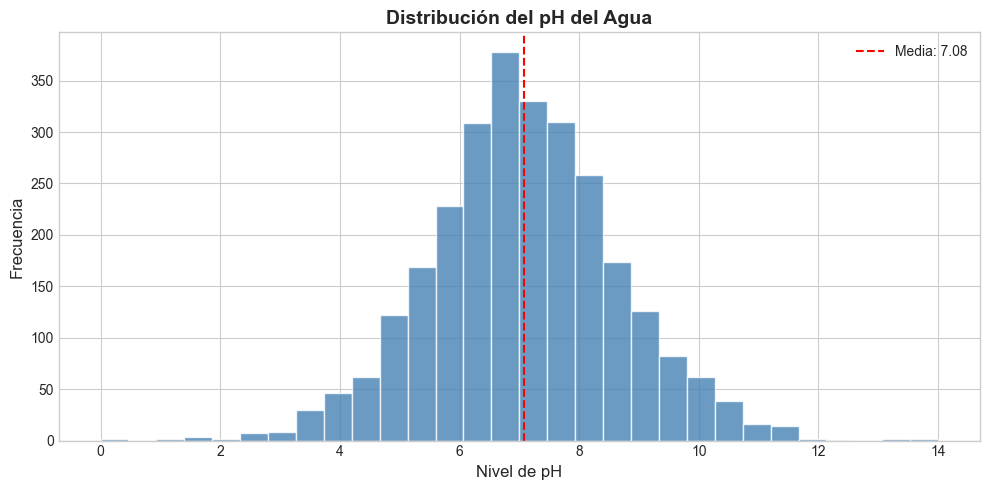

In [ ]:

# =============================================================================
# CONCEPTO: Histograma con Matplotlib
# -----------------------------------------------------------------------------
# Un histograma divide el rango de valores de una variable continua en
# intervalos (bins) y muestra cuántos datos caen en cada uno. Permite:
#   - Visualizar la distribución de una variable (normal, sesgada, bimodal).
#   - Identificar valores extremos o outliers.
#   - Evaluar si la variable tiene una distribución aproximadamente normal,
#     requisito de muchas pruebas estadísticas paramétricas.
#
# Parámetros clave:
#   bins=30:    número de intervalos; más bins → más detalle, menos suavizado.
#   alpha=0.8:  transparencia de las barras (0=transparente, 1=sólido).
#   axvline():  traza una línea vertical (aquí marca la media en rojo).
#
# CRITERIO DE USO: Aplicar como primer gráfico exploratorio de cualquier
# variable numérica continua para entender su distribución before hacer
# cálculos estadísticos o aplicar transformaciones.
# =============================================================================

plt.figure(figsize=(10, 5))

# plt.hist(): genera el histograma; dropna() excluye NaN que causarían error
plt.hist(df['ph'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)

# Etiquetas de ejes y título descriptivo del gráfico
plt.xlabel('Nivel de pH', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución del pH del Agua', fontsize=14, fontweight='bold')

# Línea de referencia en la media: ayuda a ver si la distribución es simétrica
plt.axvline(df['ph'].mean(), color='red', linestyle='--', label=f"Media: {df['ph'].mean():.2f}")
plt.legend()
plt.tight_layout()   # Ajusta márgenes para evitar que etiquetas se corten
plt.show()


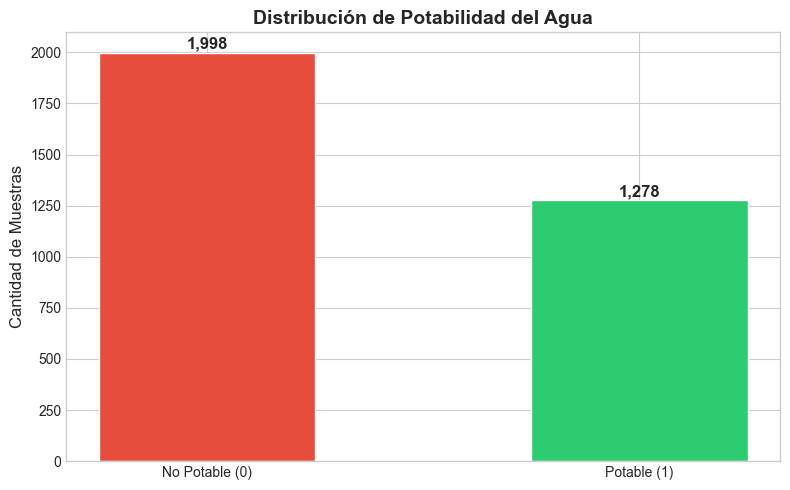

In [ ]:

# =============================================================================
# CONCEPTO: Gráfico de barras con Matplotlib
# -----------------------------------------------------------------------------
# Un gráfico de barras compara cantidades entre categorías discretas. Es
# adecuado para variables categóricas o variables target binarias como
# Potability (0/1).
#
# Elementos clave de este gráfico:
#   - value_counts():     cuenta las ocurrencias de cada valor en la columna.
#   - sort_index():       ordena por índice (0 antes que 1) para consistencia.
#   - plt.bar():          dibuja las barras con colores y ancho personalizados.
#   - Etiquetas de valor: se añaden sobre cada barra con plt.text() para
#                         comunicar el dato exacto sin que el lector interpole.
#   - zip(barras, valores): itera simultáneamente sobre barras y sus valores
#                           para posicionar cada etiqueta correctamente.
#
# CRITERIO DE USO: Usar para visualizar distribución de clases (balanceo),
# frecuencias de categorías o conteos dentro de grupos.
# =============================================================================

conteo = df['Potability'].value_counts().sort_index()
etiquetas = ['No Potable (0)', 'Potable (1)']
colores = ['#e74c3c', '#2ecc71']  # Rojo = no potable, Verde = potable

plt.figure(figsize=(8, 5))
barras = plt.bar(etiquetas, conteo.values, color=colores, edgecolor='white', width=0.5)

# Agregar etiquetas de valor sobre cada barra
# barra.get_x() + ancho/2 → centra la etiqueta horizontalmente sobre la barra
# barra.get_height() + 20  → coloca la etiqueta ligeramente por encima del tope
for barra, valor in zip(barras, conteo.values):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 20,
             f'{valor:,}', ha='center', fontsize=12, fontweight='bold')

plt.ylabel('Cantidad de Muestras', fontsize=12)
plt.title('Distribución de Potabilidad del Agua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


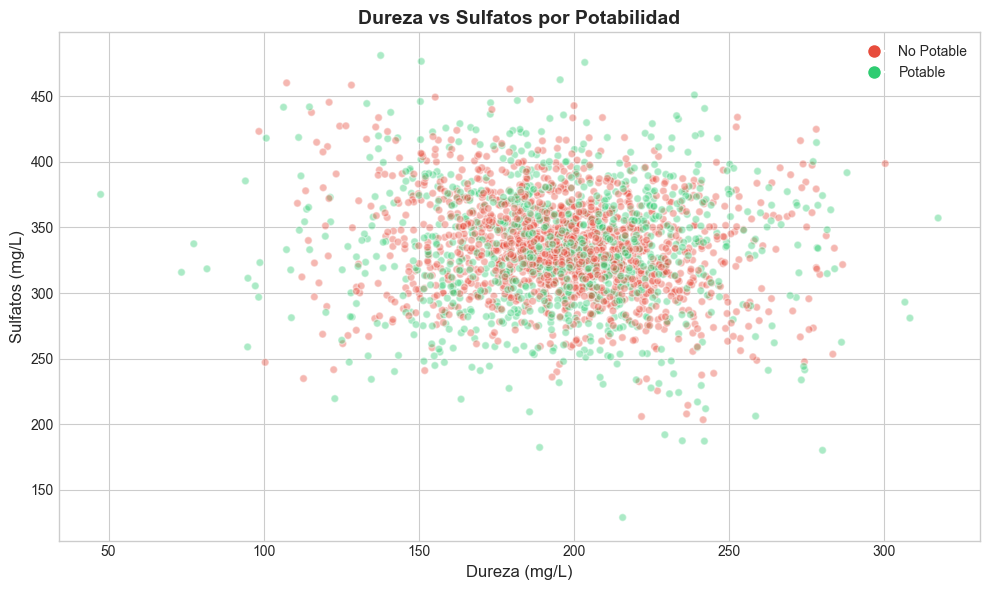

In [ ]:

# =============================================================================
# CONCEPTO: Scatter plot (diagrama de dispersión) con Matplotlib
# -----------------------------------------------------------------------------
# Un scatter plot muestra la relación entre dos variables numéricas continuas.
# Cada punto representa una observación. Permite identificar:
#   - Correlación positiva o negativa entre variables.
#   - Clusters o grupos naturales en los datos.
#   - Outliers que se alejan del patrón general.
#
# Al colorear por una tercera variable (Potability), se convierte en un
# gráfico multivariado que agrega contexto categórico.
#
# Elementos clave:
#   - dropna(subset=[...]): elimina filas con NaN en las columnas graficadas,
#     evitando errores y garantizando que color y posición correspondan al mismo registro.
#   - List comprehension para colores: asigna un color por categoría.
#   - alpha=0.4: transparencia alta para visualizar zonas de alta densidad
#     de puntos (superposición/solapamiento).
#   - Line2D: objeto de Matplotlib para construir una leyenda personalizada
#     cuando los colores no provienen de una columna de hue de seaborn.
#
# CRITERIO DE USO: Usar para explorar relaciones bivariadas y evaluar si
# dos variables se asocian o pueden separar clases en clasificación.
# =============================================================================

# Eliminar filas con NaN en las columnas relevantes para evitar inconsistencias
df_clean = df.dropna(subset=['Hardness', 'Sulfate', 'Potability'])

plt.figure(figsize=(10, 6))

# Asignación de color por potabilidad mediante comprensión de lista
colores_scatter = ['#e74c3c' if p == 0 else '#2ecc71' for p in df_clean['Potability']]
plt.scatter(df_clean['Hardness'], df_clean['Sulfate'],
            c=colores_scatter, alpha=0.4, edgecolors='white', s=30)

plt.xlabel('Dureza (mg/L)', fontsize=12)
plt.ylabel('Sulfatos (mg/L)', fontsize=12)
plt.title('Dureza vs Sulfatos por Potabilidad', fontsize=14, fontweight='bold')

# Leyenda manual con Line2D (necesaria porque plt.scatter no gestiona leyenda
# automáticamente cuando los colores se pasan como lista)
from matplotlib.lines import Line2D
leyenda = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='No Potable'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Potable')]
plt.legend(handles=leyenda)
plt.tight_layout()
plt.show()


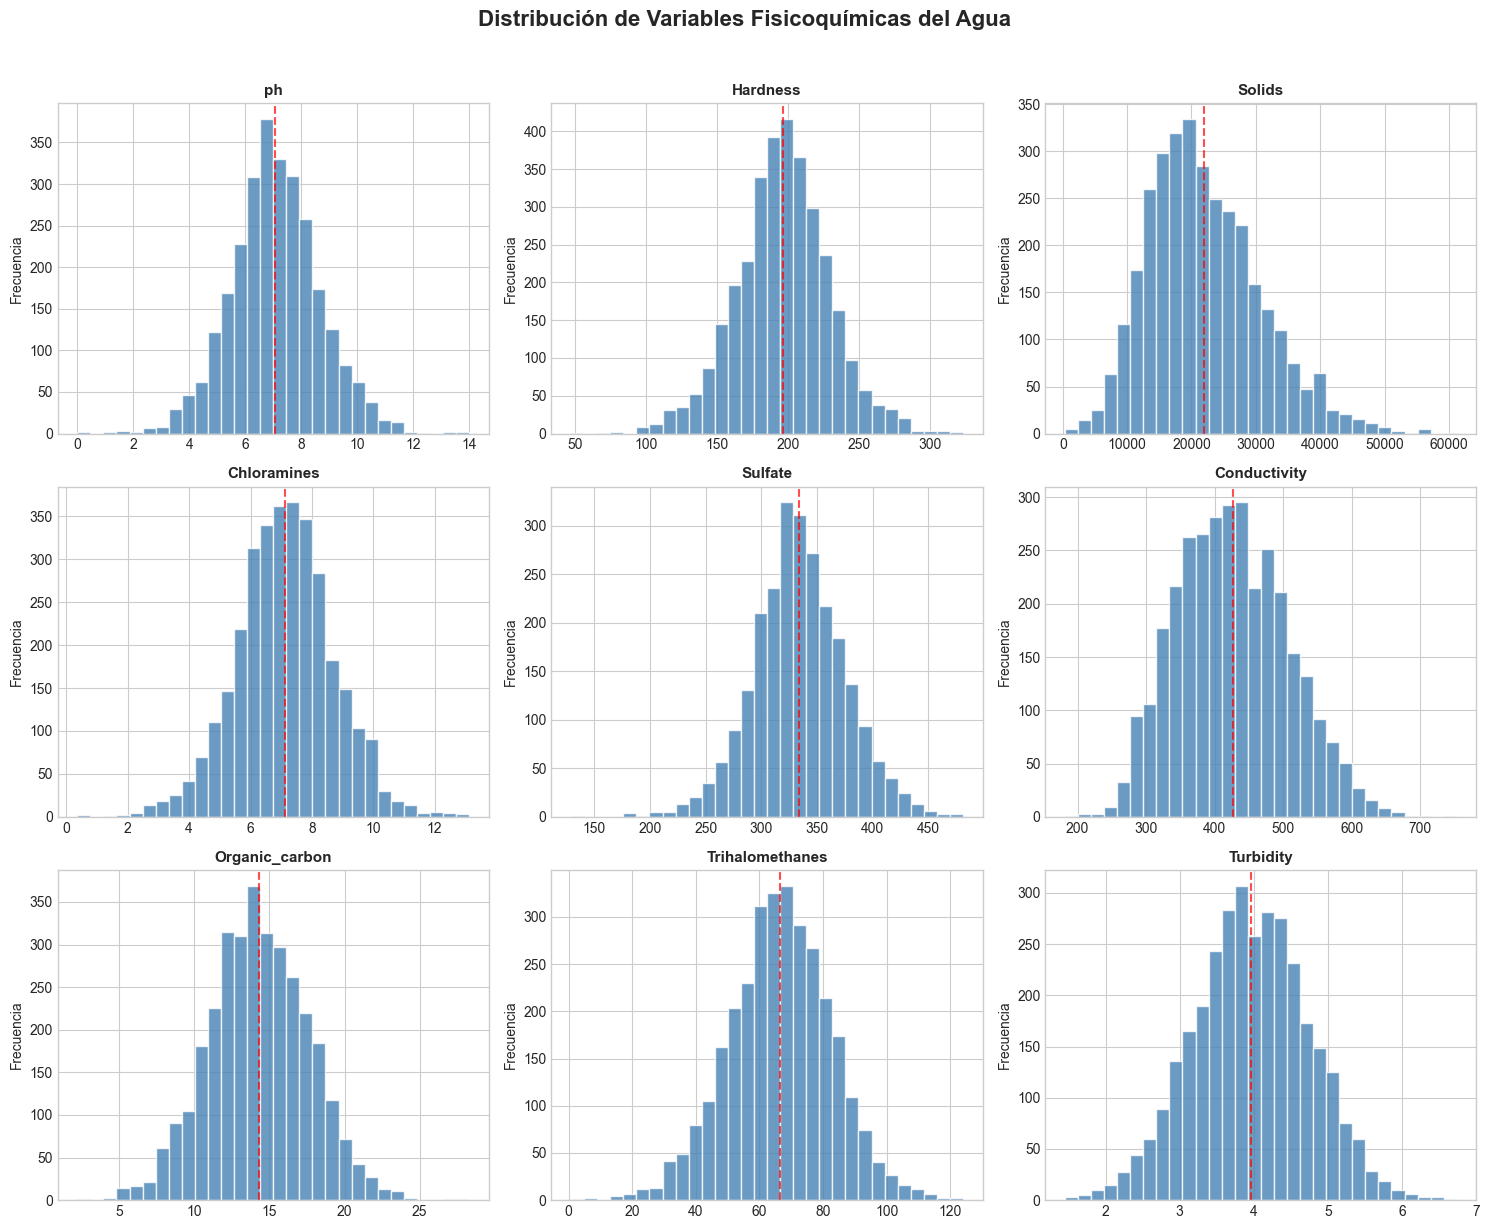

In [ ]:

# =============================================================================
# CONCEPTO: Subplots — cuadrícula de gráficos con Matplotlib
# -----------------------------------------------------------------------------
# plt.subplots(filas, columnas) crea una cuadrícula de ejes (axes) en una sola
# figura. Es útil para comparar múltiples variables simultáneamente sin generar
# una figura separada por cada una.
#
# Elementos clave:
#   - fig, axes = plt.subplots(3, 3): crea una grilla 3×3 (9 subgráficos).
#   - axes[i//3, i%3]: accede a cada subgráfico por posición de fila y columna
#     usando división entera (//) y módulo (%) para mapear el índice lineal i
#     a coordenadas de grilla (fila, columna).
#   - fig.suptitle(): título general que abarca toda la figura (no un subplot).
#   - select_dtypes(include=[np.number]): selecciona solo columnas numéricas
#     automáticamente, adaptándose a cualquier dataset.
#   - axvline con la media: línea de referencia visual en cada histograma.
#   - plt.tight_layout(): evita solapamiento entre títulos y etiquetas de
#     subgráficos adyacentes.
#
# CRITERIO DE USO: Aplicar cuando se desea un panel de EDA (Análisis
# Exploratorio de Datos) que muestre la distribución de todas las variables
# de un vistazo, facilitando la detección de asimetrías, bimodalidad u outliers.
# =============================================================================

# Selección dinámica de columnas numéricas excluyendo la variable objetivo (target)
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_numericas = [c for c in columnas_numericas if c != 'Potability']

# Cuadrícula 3×3 → una celda por cada variable fisicoquímica (9 variables)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribución de Variables Fisicoquímicas del Agua', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(columnas_numericas):
    ax = axes[i // 3, i % 3]          # Posición en la grilla: fila y columna
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    media = df[col].mean()
    ax.axvline(media, color='red', linestyle='--', alpha=0.7)  # Línea de media

plt.tight_layout()
plt.show()


---
## 8. Visualización con Seaborn

**Seaborn** está construido sobre Matplotlib y ofrece una interfaz de alto nivel para crear gráficos estadísticos atractivos con menos código. Ideal para:
- Matrices de correlación
- Distribuciones por categorías
- Gráficos multivariados

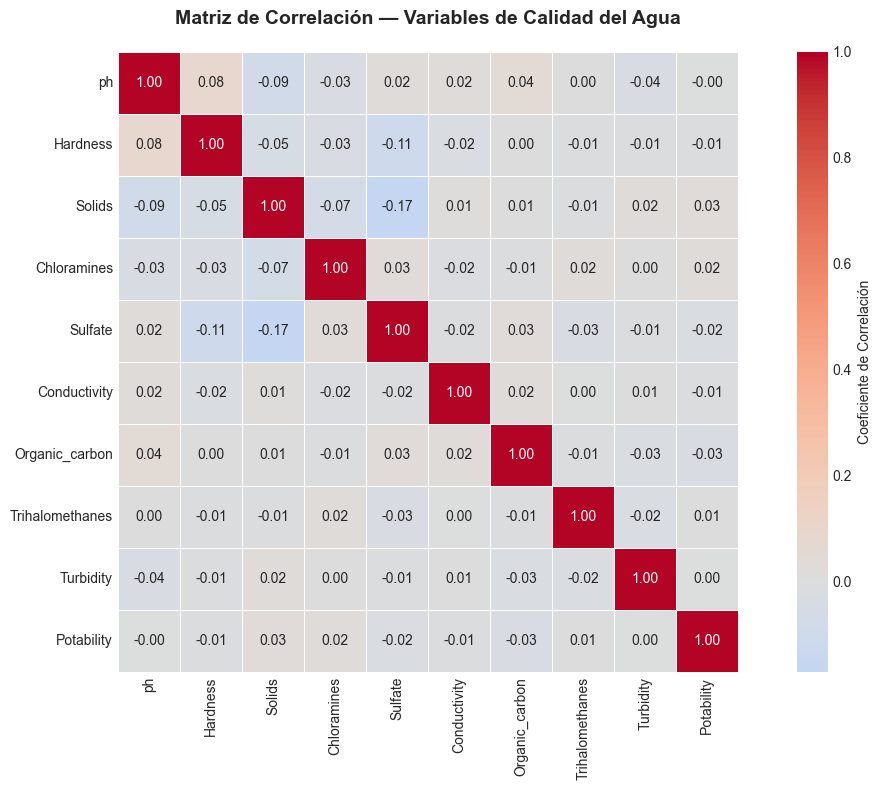

In [ ]:

# =============================================================================
# CONCEPTO: Mapa de calor de correlación con Seaborn
# -----------------------------------------------------------------------------
# La correlación de Pearson mide la relación lineal entre dos variables
# numéricas. Su valor va de -1 a 1:
#   +1: correlación positiva perfecta (al crecer una, crece la otra).
#    0: sin relación lineal.
#   -1: correlación negativa perfecta (al crecer una, decrece la otra).
#
# Un heatmap (mapa de calor) representa la matriz de correlación como una
# cuadrícula de colores, facilitando la identificación visual de relaciones.
#
# Parámetros clave de sns.heatmap():
#   annot=True:   muestra el valor numérico en cada celda.
#   cmap='coolwarm': paleta divergente; azul=negativo, blanco=0, rojo=positivo.
#   fmt='.2f':    formato de los valores a 2 decimales.
#   center=0:     ancla el color blanco en 0, haciendo legible la divergencia.
#   square=True:  celdas cuadradas para facilitar la lectura diagonal.
#
# CRITERIO DE USO:
#   - Aplicar antes de construir modelos de regresión para detectar
#     multicolinealidad (correlaciones altas entre predictores, > 0.8).
#   - Identificar qué variables tienen mayor correlación con la variable
#     objetivo (Potability) para priorizar en el modelado.
# =============================================================================

plt.figure(figsize=(12, 8))

# df.corr() calcula la matriz de correlación de Pearson para todas las columnas numéricas
correlacion = df.corr(numeric_only=True)

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, center=0, square=True,
            cbar_kws={'label': 'Coeficiente de Correlación'})

plt.title('Matriz de Correlación — Variables de Calidad del Agua',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_33488\3270045923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Potability', y='ph', palette=['#e74c3c', '#2ecc71'])


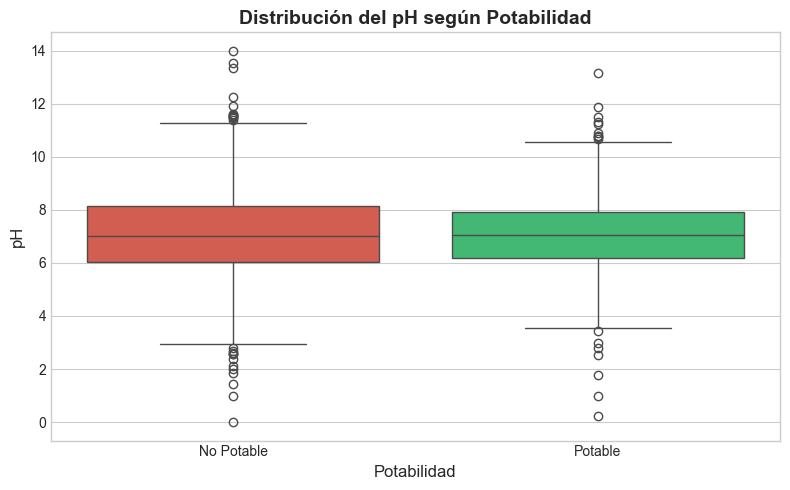

In [ ]:

# =============================================================================
# CONCEPTO: Boxplot (diagrama de caja) con Seaborn
# -----------------------------------------------------------------------------
# Un boxplot resume la distribución de una variable numérica en 5 estadísticos:
#   - Mínimo (bigote inferior): valor más bajo sin contar outliers.
#   - Percentil 25 (Q1): borde inferior de la caja.
#   - Mediana (Q2): línea interior de la caja.
#   - Percentil 75 (Q3): borde superior de la caja.
#   - Máximo (bigote superior): valor más alto sin contar outliers.
#   - Puntos fuera de los bigotes: outliers (valores > 1.5 × IQR).
#
# Al agrupar por una variable categórica (x='Potability'), se comparan las
# distribuciones entre grupos, permitiendo detectar diferencias estadísticas.
#
# Parámetros clave de sns.boxplot():
#   data: DataFrame fuente.
#   x:    variable categórica que define los grupos (eje X).
#   y:    variable numérica a distribuir (eje Y).
#   palette: lista de colores, uno por categoría.
#
# CRITERIO DE USO: Usar para comparar distribuciones entre grupos y evaluar
# si una variable discrimina bien entre categorías (ej. clases de un modelo).
# =============================================================================

plt.figure(figsize=(8, 5))

# sns.boxplot con x='Potability' divide el eje X en dos grupos (0 y 1)
# y dibuja una caja por grupo mostrando su distribución de pH
sns.boxplot(data=df, x='Potability', y='ph', palette=['#e74c3c', '#2ecc71'])

# Reemplazar etiquetas numéricas (0, 1) con texto descriptivo para claridad
plt.xticks([0, 1], ['No Potable', 'Potable'])
plt.xlabel('Potabilidad', fontsize=12)
plt.ylabel('pH', fontsize=12)
plt.title('Distribución del pH según Potabilidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


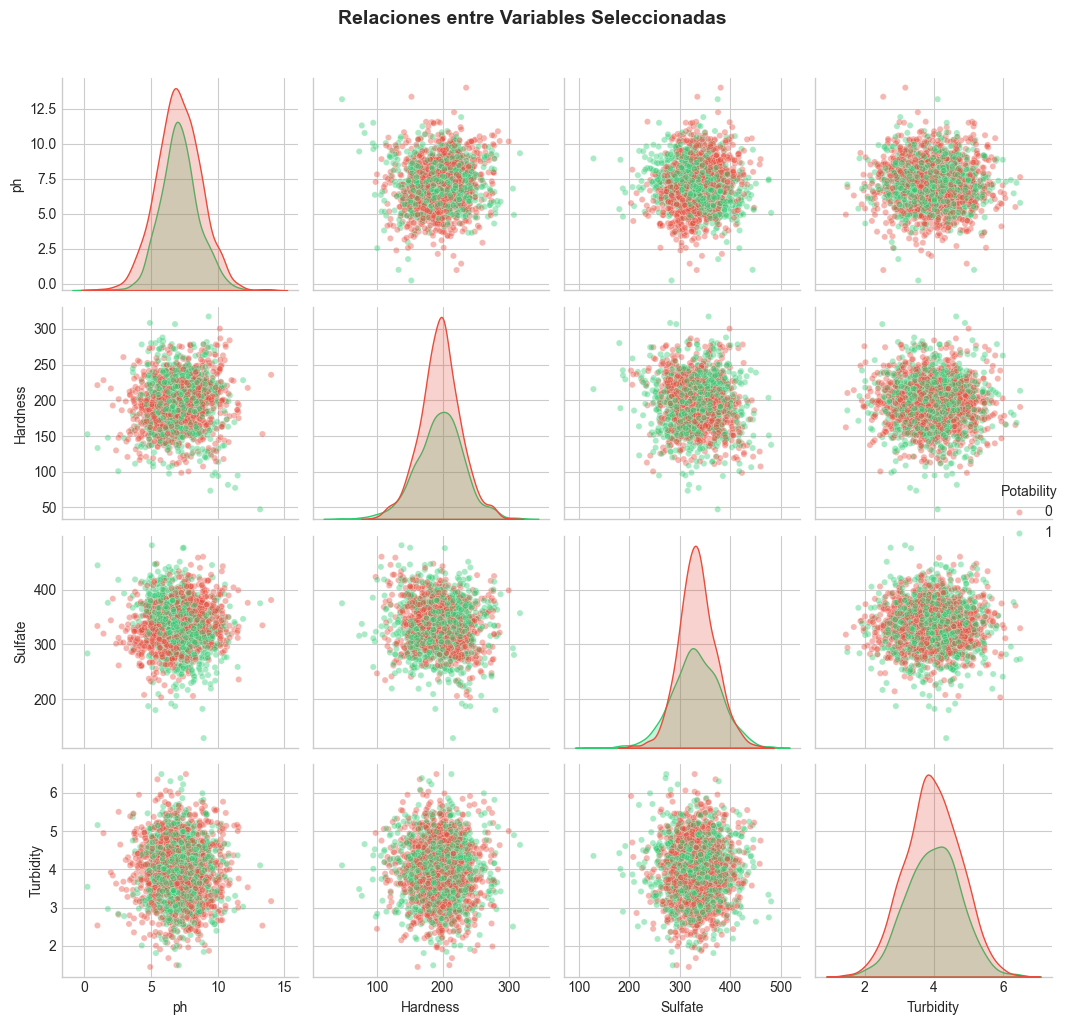

In [ ]:

# =============================================================================
# CONCEPTO: Pairplot — visualización multivariada con Seaborn
# -----------------------------------------------------------------------------
# Un pairplot genera una cuadrícula donde cada par de variables tiene su propio
# scatter plot. En la diagonal se muestran las distribuciones univariadas.
#
# Esto permite explorar de forma simultánea:
#   - Relaciones bivariadas entre todas las variables seleccionadas.
#   - Si los grupos (hue) se separan visualmente en alguna combinación.
#
# Parámetros clave de sns.pairplot():
#   hue='Potability':   colorea los puntos según la clase (0 o 1).
#   diag_kind='kde':    en la diagonal, muestra una curva KDE (distribución
#                       suavizada) en lugar de un histograma; útil para comparar
#                       distribuciones entre clases.
#   plot_kws={'alpha'}: controla la transparencia de los puntos en los scatter.
#
# dropna(): es obligatorio porque pairplot no maneja NaN nativamente.
#
# CRITERIO DE USO: Usar en la fase de EDA multivariado para seleccionar las
# variables más prometedoras para el modelado. Útil con un subconjunto de
# variables (4-6) para que la cuadrícula sea legible.
# =============================================================================

# Selección de variables representativas para mantener la legibilidad del gráfico
columnas_pairplot = ['ph', 'Hardness', 'Sulfate', 'Turbidity', 'Potability']
df_pairplot = df[columnas_pairplot].dropna()  # Elimina filas con NaN en las columnas seleccionadas

sns.pairplot(df_pairplot, hue='Potability', palette=['#e74c3c', '#2ecc71'],
             diag_kind='kde',                # Distribución suavizada en la diagonal
             plot_kws={'alpha': 0.4, 's': 20})  # Puntos semitransparentes y pequeños

plt.suptitle('Relaciones entre Variables Seleccionadas', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_33488\3373204931.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Potability', y='Turbidity',


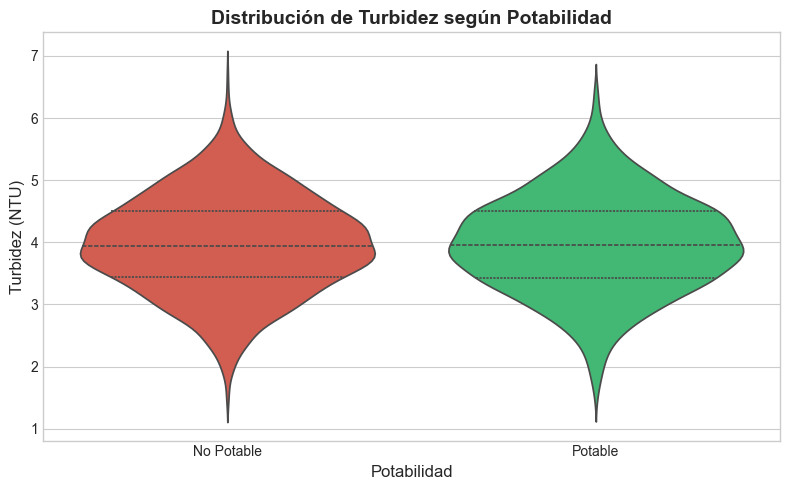

In [ ]:

# =============================================================================
# CONCEPTO: Violin plot con Seaborn
# -----------------------------------------------------------------------------
# Un violin plot combina un boxplot con una estimación de densidad kernel (KDE)
# en cada lado. Esto permite ver:
#   - La forma completa de la distribución (no solo los cuartiles del boxplot).
#   - Si la distribución es unimodal, bimodal o tiene colas largas.
#   - Diferencias en la forma entre grupos (no solo en la mediana o rango).
#
# Ventaja sobre el boxplot: el violin muestra si hay dos picos (bimodalidad)
# que el boxplot oculta al resumir todo en 5 estadísticos.
#
# Parámetros clave:
#   inner='quartile':  dibuja líneas dentro del violin marcando los cuartiles
#                      (Q1, mediana, Q3), añadiendo la información del boxplot.
#
# CRITERIO DE USO: Preferir violin plot sobre boxplot cuando se sospecha que
# la distribución no es simétrica ni unimodal, o cuando se quiere comunicar
# la forma de la distribución de forma más completa a una audiencia técnica.
# =============================================================================

plt.figure(figsize=(8, 5))

# inner='quartile' agrega marcas de cuartiles al interior del violin,
# combinando la información distribucional con la del boxplot
sns.violinplot(data=df, x='Potability', y='Turbidity',
               palette=['#e74c3c', '#2ecc71'], inner='quartile')

plt.xticks([0, 1], ['No Potable', 'Potable'])
plt.xlabel('Potabilidad', fontsize=12)
plt.ylabel('Turbidez (NTU)', fontsize=12)
plt.title('Distribución de Turbidez según Potabilidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


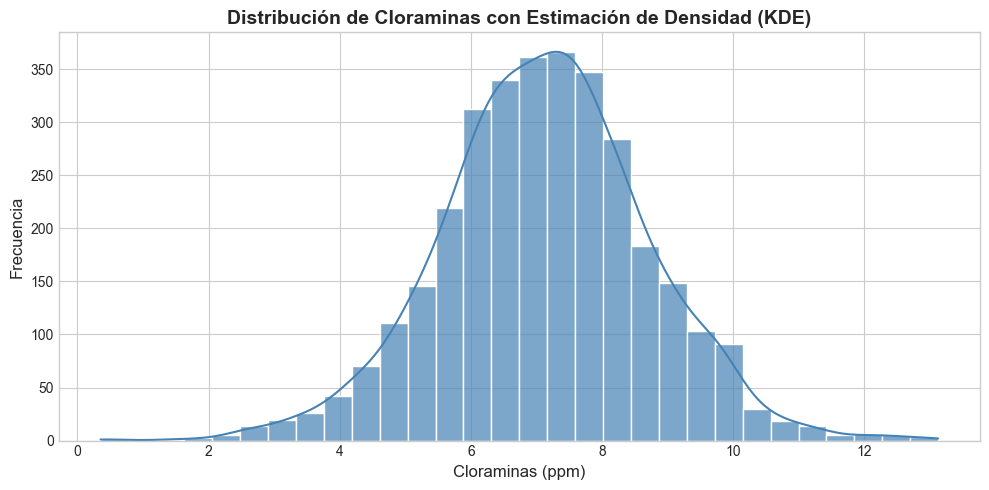

In [ ]:

# =============================================================================
# CONCEPTO: Histograma con KDE (Kernel Density Estimation) usando Seaborn
# -----------------------------------------------------------------------------
# sns.histplot() con kde=True superpone una curva de densidad suavizada sobre
# el histograma. La curva KDE:
#   - Estima la función de densidad de probabilidad de la variable.
#   - Suaviza las irregularidades que aparecen al cambiar el número de bins.
#   - Permite comparar visualmente la distribución con formas teóricas (normal).
#
# Diferencia respecto a plt.hist():
#   - Seaborn integra histograma + KDE en una sola función con menos código.
#   - El estilo visual es más refinado por defecto.
#   - Permite agregar coloreado por hue directamente.
#
# Parámetros clave:
#   kde=True:    activa la curva de densidad superpuesta.
#   bins=30:     número de intervalos del histograma base.
#   alpha=0.7:   transparencia para que la curva KDE sea visible sobre las barras.
#
# CRITERIO DE USO: Usar cuando se quiere evaluar si una variable sigue una
# distribución normal o para comunicar la distribución de forma más suave
# y continua que un histograma puro.
# =============================================================================

plt.figure(figsize=(10, 5))

# kde=True: superpone automáticamente la curva de densidad kernel al histograma
sns.histplot(data=df, x='Chloramines', kde=True, bins=30,
             color='steelblue', edgecolor='white', alpha=0.7)

plt.xlabel('Cloraminas (ppm)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Cloraminas con Estimación de Densidad (KDE)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 9. Visualización con Plotly Express

**Plotly Express** permite crear gráficos **interactivos** con pocas líneas de código. Los gráficos permiten:
- Hacer zoom
- Ver información al pasar el cursor (hover)
- Filtrar y seleccionar datos
- Exportar como imagen

In [ ]:

# =============================================================================
# CONCEPTO: Histograma interactivo con Plotly Express
# -----------------------------------------------------------------------------
# px.histogram() genera un histograma interactivo (HTML/JavaScript). La
# interactividad incluye zoom, desplazamiento, tooltips al pasar el cursor y
# la posibilidad de ocultar/mostrar series haciendo clic en la leyenda.
#
# Parámetros clave:
#   color='Potability_label':  genera una barra por categoría en cada bin,
#                              diferenciando visualmente los grupos.
#   barmode='overlay':         superpone las barras de ambas clases en el mismo
#                              eje (alternativa: 'group' las coloca lado a lado).
#   nbins=40:                  número de intervalos del histograma.
#   opacity=0.7:               transparencia para ver la superposición de grupos.
#   color_discrete_map:        diccionario que asigna colores específicos a
#                              cada categoría por nombre.
#   labels:                    diccionario para renombrar ejes y leyendas con
#                              texto más descriptivo que los nombres de columnas.
#
# Preparación previa: se crea 'Potability_label' con .map() para reemplazar
# los valores numéricos (0, 1) por etiquetas legibles en la leyenda.
#
# CRITERIO DE USO: Usar Plotly para presentaciones, dashboards o exploración
# interactiva donde el usuario necesita examinar los datos en detalle.
# =============================================================================

# Copia del DataFrame para agregar la columna de etiqueta sin modificar el original
df_plotly = df.copy()

# .map() transforma valores numéricos en etiquetas de texto para la leyenda
df_plotly['Potability_label'] = df_plotly['Potability'].map({0: 'No Potable', 1: 'Potable'})

fig = px.histogram(
    df_plotly.dropna(subset=['Solids']),   # Excluye filas con NaN en la variable graficada
    x='Solids',
    color='Potability_label',              # Colorea por clase (superpone dos histogramas)
    barmode='overlay',                     # Superpone las barras para comparar distribuciones
    nbins=40,
    title='Distribución de Sólidos Disueltos por Potabilidad',
    labels={'Solids': 'Sólidos Disueltos (ppm)', 'count': 'Frecuencia', 'Potability_label': 'Potabilidad'},
    color_discrete_map={'No Potable': '#e74c3c', 'Potable': '#2ecc71'},
    opacity=0.7
)
fig.show()


In [ ]:

# =============================================================================
# CONCEPTO: Scatter plot interactivo con Plotly Express
# -----------------------------------------------------------------------------
# px.scatter() genera un diagrama de dispersión interactivo. A diferencia de
# Matplotlib, permite al usuario:
#   - Hacer hover sobre cada punto para ver sus valores exactos.
#   - Hacer zoom en áreas de interés.
#   - Filtrar clases haciendo clic en la leyenda.
#
# Parámetro clave — hover_data:
#   Lista de columnas adicionales que se muestran en el tooltip al pasar
#   el cursor sobre un punto. Esto añade contexto sin saturar el gráfico,
#   permitiendo inspeccionar individuos de interés en la nube de puntos.
#
# Diferencia con Matplotlib:
#   - Matplotlib: gráfico estático, sin interacción post-renderizado.
#   - Plotly: gráfico dinámico, ideal para exploración y presentaciones.
#
# CRITERIO DE USO: Usar px.scatter() cuando se quiere identificar puntos
# individuales específicos (ej. outliers) o cuando el usuario final necesita
# explorar los datos sin reescribir código.
# =============================================================================

fig = px.scatter(
    df_plotly.dropna(subset=['Hardness', 'Conductivity']),
    x='Hardness',
    y='Conductivity',
    color='Potability_label',              # Colorea puntos por clase
    hover_data=['ph', 'Turbidity', 'Sulfate'],  # Variables mostradas en el tooltip interactivo
    title='Dureza vs Conductividad por Potabilidad',
    labels={'Hardness': 'Dureza (mg/L)', 'Conductivity': 'Conductividad (μS/cm)',
            'Potability_label': 'Potabilidad'},
    color_discrete_map={'No Potable': '#e74c3c', 'Potable': '#2ecc71'},
    opacity=0.5    # Transparencia para manejar el solapamiento de puntos
)
fig.show()


In [ ]:

# =============================================================================
# CONCEPTO: Boxplot interactivo multi-variable con Plotly Express
# -----------------------------------------------------------------------------
# Este gráfico compara las distribuciones de varias variables en un solo panel
# usando px.box(). Para que todas las variables quepan en el mismo eje Y,
# primero se reestructura el DataFrame de formato ancho a formato largo.
#
# Transformación con df.melt():
#   - Formato ancho: cada variable es una columna separada (formato original).
#   - Formato largo: una columna 'Variable' contiene el nombre de la variable
#     y otra columna 'Valor' contiene su valor numérico. Cada fila original
#     se convierte en tantas filas como variables existan.
#   - var_name='Variable': nombre de la columna que guardará los nombres de las variables.
#   - value_name='Valor':  nombre de la columna que guardará los valores numéricos.
#
# Ventaja: permite graficar todas las variables en un único gráfico usando
# x='Variable' sin necesidad de crear 9 subplots separados.
#
# showlegend=False: la leyenda sería redundante porque el eje X ya muestra
# los nombres de las variables.
#
# CRITERIO DE USO: Usar melt + boxplot cuando se quiere comparar la dispersión
# y rango de múltiples variables con distintas escalas en una vista consolidada.
# =============================================================================

from sklearn.preprocessing import MinMaxScaler  # Disponible si se necesita normalizar previamente

# Lista de variables fisicoquímicas a comparar (excluye la variable target)
cols_num = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
            'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

# melt(): convierte de formato ancho (9 columnas) a formato largo (2 columnas)
# Resultado: columnas 'Variable' (nombre) y 'Valor' (dato numérico)
df_melt = df[cols_num].melt(var_name='Variable', value_name='Valor')

fig = px.box(
    df_melt.dropna(),
    x='Variable',    # Eje X: nombre de cada variable fisicoquímica
    y='Valor',       # Eje Y: distribución de valores de cada variable
    color='Variable',
    title='Distribución de Variables Fisicoquímicas del Agua',
    labels={'Valor': 'Valor', 'Variable': 'Variable'}
)
fig.update_layout(showlegend=False, xaxis_tickangle=-45)  # Rota etiquetas para legibilidad
fig.show()


In [ ]:

# =============================================================================
# CONCEPTO: Gráfico de barras agrupadas interactivo con Plotly Express
# -----------------------------------------------------------------------------
# Este gráfico compara los valores promedio de cada variable fisicoquímica
# entre muestras potables y no potables. Permite identificar si existe alguna
# diferencia sistemática en los promedios que pueda usarse como señal
# discriminativa para un modelo de clasificación.
#
# Pipeline de transformación de datos:
#   1. df.groupby('Potability')[cols_num].mean(): calcula la media de cada
#      variable numérica agrupada por la clase Potability (0 y 1).
#   2. .reset_index(): convierte el índice jerárquico del groupby en columna.
#   3. .map(): agrega etiquetas de texto a los valores 0/1 de Potability.
#   4. .melt(): convierte de formato ancho a largo para que px.bar() pueda
#      separar cada variable en una posición del eje X.
#
# barmode='group': coloca las barras de cada clase una al lado de la otra
# (en lugar de apilarlas), facilitando la comparación directa de promedios.
#
# CRITERIO DE USO: Aplicar cuando se quiere comunicar diferencias entre grupos
# en múltiples variables simultáneamente. Si existen diferencias claras en
# alguna variable, esa variable tiene potencial predictivo en un modelo.
# =============================================================================

# Paso 1: Calcular promedio de variables numéricas por grupo de potabilidad
promedios = df.groupby('Potability')[cols_num].mean().reset_index()

# Paso 2: Agregar etiqueta textual para la leyenda del gráfico
promedios['Potability_label'] = promedios['Potability'].map({0: 'No Potable', 1: 'Potable'})

# Paso 3: Convertir a formato largo para px.bar()
# id_vars: columna que identifica el grupo (se mantiene como referencia)
# value_vars: las 9 variables numéricas que se convertirán en filas
promedios_melt = promedios.melt(
    id_vars=['Potability_label'],
    value_vars=cols_num,
    var_name='Variable',
    value_name='Promedio'
)

# Paso 4: Gráfico de barras agrupadas
fig = px.bar(
    promedios_melt,
    x='Variable',                # Eje X: nombre de la variable fisicoquímica
    y='Promedio',                # Eje Y: valor promedio de la variable
    color='Potability_label',    # Color distingue las dos clases
    barmode='group',             # Barras lado a lado (no apiladas)
    title='Valores Promedio por Variable según Potabilidad',
    labels={'Promedio': 'Valor Promedio', 'Variable': 'Variable', 'Potability_label': 'Potabilidad'},
    color_discrete_map={'No Potable': '#e74c3c', 'Potable': '#2ecc71'}
)
fig.update_layout(xaxis_tickangle=-45)  # Rota etiquetas del eje X para mayor legibilidad
fig.show()


---
## 10. Conclusiones

En este notebook aprendimos a:

1. **Cargar datos** desde múltiples fuentes:
   - Archivos CSV locales con `pd.read_csv()`
   - Archivos Excel con `pd.read_excel()`
   - Repositorios de GitHub usando URLs raw
   - Google Sheets mediante URLs de exportación

2. **Explorar los datos** con funciones esenciales de pandas: `.shape`, `.info()`, `.describe()`, `.dtypes`, `.isnull().sum()`

3. **Visualizar datos** con tres librerías complementarias:
   - **Matplotlib**: Control total, ideal para publicaciones y gráficos estáticos
   - **Seaborn**: Gráficos estadísticos elegantes con menos código
   - **Plotly Express**: Gráficos interactivos ideales para exploración

### Hallazgos preliminares sobre el dataset de calidad del agua:
- El dataset contiene valores nulos en varias columnas (especialmente en `ph`, `Sulfate` y `Trihalomethanes`)
- Existe un desbalance de clases en la variable `Potability`
- Las variables numéricas presentan diferentes escalas y distribuciones

**Próxima semana:** Abordaremos la calidad, limpieza y transformación de estos datos para prepararlos para el análisis estadístico y modelado.